In [1]:
import sys
import logging
import concurrent.futures
import time
from datetime import datetime
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer, CRS
from shapely.geometry import Polygon, Point, MultiPolygon, mapping
from sliderule import sliderule, icesat2, earthdata, h5
import geojson
import numpy as np

In [2]:
# Configure ICESat-2 API
icesat2.init("slideruleearth.io", verbose=True)

### Download data over Tuolumne bounding box:

In [25]:
# define tuolumne bounding box:
region = [  {"lon": -119.8, "lat": 37.7},
            {"lon": -119.2, "lat": 37.7},
            {"lon": -119.2, "lat": 38.2},
            {"lon": -119.8, "lat": 38.2},
            {"lon": -119.8, "lat": 37.7}  ]

In [18]:
# Get 3dep request:

geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 10 meter', polygon=region)

### Test slope and aspect sampling:

In [22]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {
        "3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson, "fjkd":True} #
                }, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}

#gdf = raster.sample("usgs3dep-10meter-dem", [[-108.0,39.0]], {"slope_aspect": True, "slope_scale_length": 40})
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

In [23]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_slope = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_slope["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_slope["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_slope.shape[0]))

Completed in 17.974 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


In [24]:
atl06_sr_slope.columns

Index(['spot', 'dh_fit_dx', 'h_sigma', 'w_surface_window_final', 'segment_id',
       'y_atc', 'x_atc', 'pflags', 'region', 'rms_misfit', 'h_mean',
       'n_fit_photons', 'gt', 'cycle', 'rgt', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       '3dep.file_id', '3dep.time', '3dep.value', '3dep.flags'],
      dtype='object')

In [27]:
from sliderule import raster

In [28]:
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "t0": "2020-10-13T00:00:00Z",
    "t1": "2021-10-13T00:00:00Z"
}

gdf = icesat2.atl06p(parms)
coordinates = [[pt.x, pt.y] for pt in gdf.geometry]

sa_gdf = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
print(sa_gdf[["slope", "aspect", "slope_count"]])

                         slope      aspect  slope_count
time                                                   
2022-12-03 18:59:21   2.814869  245.516899            9
2022-12-03 18:59:21   1.443965  192.530251            9
2022-12-03 18:59:21   0.902212  213.503409            9
2022-12-03 18:59:21   0.714425  176.495671            9
2022-12-03 18:59:21   3.395198  254.863744            9
...                        ...         ...          ...
2022-12-03 18:59:21   9.165257  306.891844            9
2022-12-03 18:59:21   2.644976   50.371221            9
2022-12-03 18:59:21   8.164163   19.022705            9
2022-12-03 18:59:21  11.208770  154.850743            9
2022-12-03 18:59:21  10.492635  138.092606            9

[113632 rows x 3 columns]


In [29]:
sa_gdf

,slope_count,slope,aspect,file,value,geometry
time,,,,,,
2022-12-03 18:59:21,9,2.814869,245.516899,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2324.634097,POINT (-119.79496 38.12538)
2022-12-03 18:59:21,9,1.443965,192.530251,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2324.456419,POINT (-119.79499 38.1252)
2022-12-03 18:59:21,9,0.902212,213.503409,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2324.313410,POINT (-119.79501 38.12502)
2022-12-03 18:59:21,9,0.714425,176.495671,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2324.163078,POINT (-119.79503 38.12484)
2022-12-03 18:59:21,9,3.395198,254.863744,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2323.562064,POINT (-119.79506 38.12466)
...,...,...,...,...,...,...
2022-12-03 18:59:21,9,9.165257,306.891844,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2819.539257,POINT (-119.57442 38.19652)
2022-12-03 18:59:21,9,2.644976,50.371221,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2821.064971,POINT (-119.57444 38.1967)
2022-12-03 18:59:21,9,8.164163,19.022705,/vsis3/prd-tnm/StagedProducts/Elevation/13/TIF...,2821.515978,POINT (-119.57447 38.19688)


In [34]:
gdf['slope'] = sa_gdf['slope'].values

<Axes: >

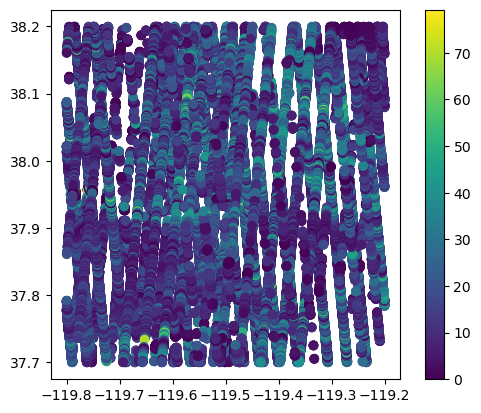

In [36]:
gdf.plot(column='slope', legend = True)

<Axes: >

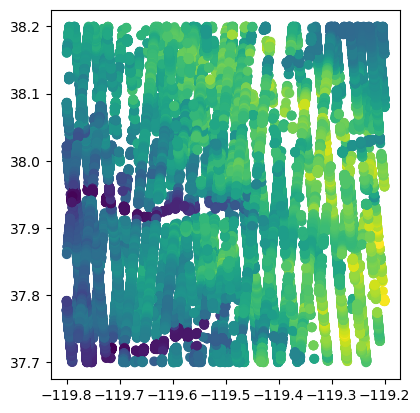

In [47]:
gdf[gdf['slope']<20].plot(column='h_mean')

<Axes: >

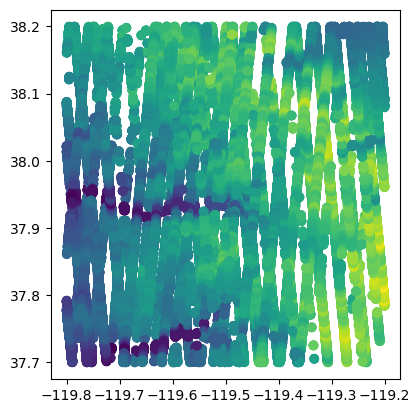

In [48]:
gdf.plot(column='h_mean')

In [49]:
gdf.shape

(113632, 22)

In [50]:
gdf[gdf['slope']<20].shape

(79832, 22)

In [51]:
np.nanmedian(gdf.loc[(gdf['slope']<20), 'h_mean'])

np.float64(2589.951424965629)

In [52]:
np.nanmedian(gdf['h_mean'])

np.float64(2646.390316949779)

In [46]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 65.787 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 111149 elevations


### Download again to test data total:

In [11]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 69.304 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


### And again:

In [26]:
# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 18.528 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


### Download without 3dep sampling to see if that changes the data total:

In [12]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 12.738 seconds of wall-clock time
Reference Ground Tracks: [ 684  707 1126 1149  265  623 1210  181]
Cycles: [ 9 10 11 12 13]
Received 113632 elevations


### download totals are consistent over tuolumne bounding box

### Now test over larger area: the Sierra

In [39]:
poly = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

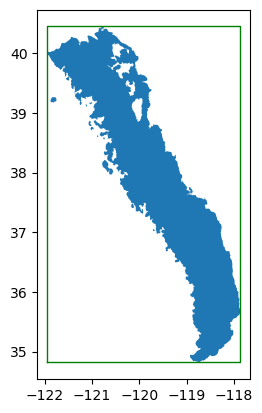

In [65]:
region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

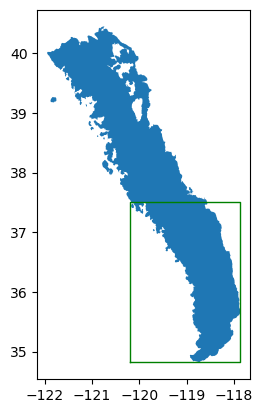

In [40]:
south_region = [  {"lon": -120.2, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 37.5},
            {"lon": -120.2, "lat": 37.5},
            {"lon": -120.2, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in south_region]
region_lat = [e["lat"] for e in south_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

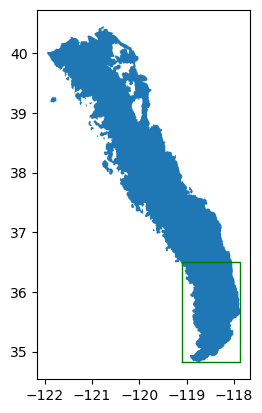

In [63]:
south_region_1 = [  {"lon": -119.1, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 36.5},
            {"lon": -119.1, "lat": 36.5},
            {"lon": -119.1, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in south_region_1]
region_lat = [e["lat"] for e in south_region_1]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

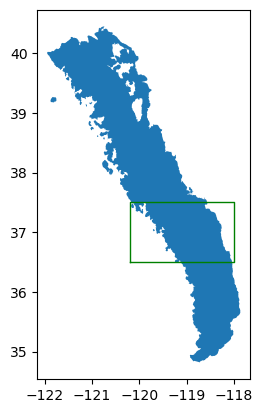

In [62]:
south_region_2 = [  {"lon": -120.2, "lat": 36.5},
            {"lon": -118, "lat": 36.5},
            {"lon": -118, "lat": 37.5},
            {"lon": -120.2, "lat": 37.5},
            {"lon": -120.2, "lat": 36.5}  ]

region_lon = [e["lon"] for e in south_region_2]
region_lat = [e["lat"] for e in south_region_2]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

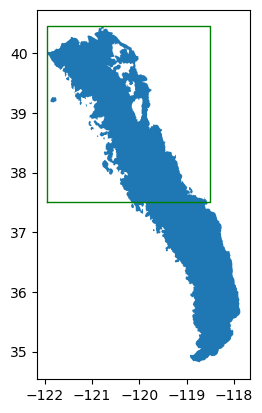

In [41]:
north_region = [  {"lon": -121.948903, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 37.5}  ]

region_lon = [e["lon"] for e in north_region]
region_lat = [e["lat"] for e in north_region]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

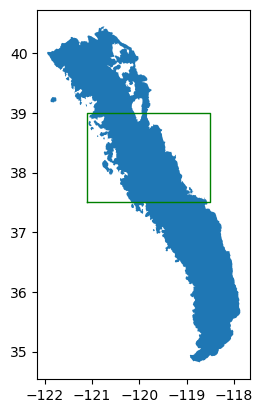

In [66]:
north_region_1 = [  {"lon": -121.1, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 39},
            {"lon": -121.1, "lat": 39},
            {"lon": -121.1, "lat": 37.5}  ]

region_lon = [e["lon"] for e in north_region_1]
region_lat = [e["lat"] for e in north_region_1]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

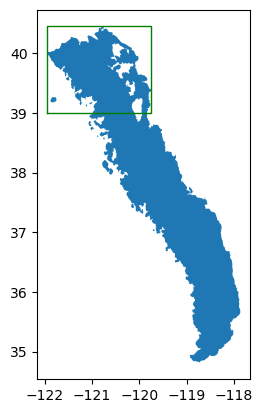

In [72]:
north_region_2 = [  {"lon": -121.948903, "lat": 39},
            {"lon": -119.75, "lat": 39},
            {"lon": -119.75, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 39}  ]

region_lon = [e["lon"] for e in north_region_2]
region_lat = [e["lat"] for e in north_region_2]

fig, ax = plt.subplots()
poly.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

### Test without 3dep first:

In [21]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 153.852 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2291624 elevations


Completed in 153.852 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2291624 elevations

### Second test without 3dep for consistency:

In [22]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 151.620 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2276988 elevations


Completed in 151.620 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2276988 elevations

In [23]:
atl06_sr

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,h_sigma,rgt,gt,n_fit_photons,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag
time,,,,,,,,,,,,,,,,,,,,,
2020-10-15 12:31:34.705626368,-3148.643311,3873082.00,12.545719,9,193116,0,619.275540,5,-0.491404,2,...,0.784603,326,50,12,POINT (-120.02903 34.81917),1.0,20.000000,-2.074179,0.0,0.0
2020-10-15 12:31:34.708440832,-3148.767822,3873102.00,17.139868,9,193117,0,608.194516,5,-0.671724,2,...,0.201030,326,50,27,POINT (-120.02905 34.81935),1.0,78.812939,-2.074168,0.0,0.0
2020-10-15 12:31:34.711251712,-3148.914307,3873122.00,17.998465,9,193118,0,594.123127,5,-0.705415,2,...,0.165203,326,50,29,POINT (-120.02907 34.81953),1.0,126.000000,-2.074159,0.0,0.0
2020-10-15 12:31:34.714062080,-3149.056641,3873142.00,16.492249,9,193119,0,580.209463,5,-0.646310,2,...,0.148351,326,50,25,POINT (-120.02909 34.81971),1.0,126.000000,-2.074159,0.0,0.0
2020-10-15 12:31:34.716871424,-3149.163818,3873162.00,11.612407,9,193120,0,569.347624,5,-0.454756,2,...,0.372001,326,50,16,POINT (-120.02911 34.81989),1.0,126.000000,-2.074159,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:11.513266176,-6739.913574,4171509.25,3.917977,13,208001,0,2349.020493,1,0.151763,2,...,0.024523,265,10,30,POINT (-119.52671 37.49932),1.0,111.000000,-1.753762,0.0,0.0
2021-10-09 19:20:11.516098560,-6739.768066,4171529.25,4.310019,13,208002,0,2352.226908,1,0.167310,2,...,0.024101,265,10,30,POINT (-119.52673 37.4995),1.0,111.000000,-1.753762,0.0,0.0
2021-10-09 19:20:11.518932480,-6739.616211,4171549.50,4.213150,13,208003,0,2355.548524,1,0.163472,2,...,0.049688,265,10,21,POINT (-119.52675 37.49968),1.0,111.000000,-1.753762,0.0,0.0


### 3rd test:

In [27]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 152.383 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2291624 elevations


In [28]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 151.706 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2291624 elevations


### Test of north region of Sierras:

In [29]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 278.920 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  623  684  707  745  768  806  829  867  890
 1065 1088 1126 1149 1187 1210 1248 1271 1332  120  181  204  242  265
  646 1309]
Cycles: [ 9 10 11 12 13]
Received 3795412 elevations


In [30]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 259.594 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  623  684  707  745  768  806  829  867  890
 1065 1088 1126 1149 1187 1210 1248 1271 1332  120  181  204  242  265
  646 1309]
Cycles: [ 9 10 11 12 13]
Received 3778063 elevations


In [31]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    # "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr["rgt"].unique()))
print("Cycles: {}".format(atl06_sr["cycle"].unique()))
print("Received {} elevations".format(atl06_sr.shape[0]))

Completed in 256.750 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  623  684  707  745  768  806  829  867  890
 1065 1088 1126 1149 1187 1210 1248 1271 1332  120  181  204  242  265
  646 1309]
Cycles: [ 9 10 11 12 13]
Received 3811929 elevations


In [32]:
atl06_sr

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,h_sigma,rgt,gt,n_fit_photons,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag
time,,,,,,,,,,,,,,,,,,,,,
2020-10-14 00:50:21.733816832,5978.400391,15569721.0,3.637513,9,777343,0,1641.960593,1,0.140617,6,...,0.046696,303,10,90,POINT (-120.54507 40.44682),1.0,20.0,-1.312476,0.0,0.0
2020-10-14 00:50:21.736616448,5978.390137,15569741.0,3.000000,9,777344,0,1644.396298,1,0.092816,6,...,0.027664,303,10,110,POINT (-120.54509 40.44664),1.0,20.0,-1.312476,0.0,0.0
2020-10-14 00:50:21.739419648,5978.399902,15569761.0,3.000000,9,777345,0,1645.587420,1,0.030053,6,...,0.039307,303,10,82,POINT (-120.54512 40.44646),1.0,20.0,-1.312461,0.0,0.0
2020-10-14 00:50:21.742228224,5978.425781,15569781.0,3.000000,9,777346,0,1645.864620,1,0.011968,6,...,0.031074,303,10,73,POINT (-120.54514 40.44628),1.0,20.0,-1.312415,0.0,0.0
2020-10-14 00:50:21.745040640,5978.459961,15569801.0,3.000000,9,777347,0,1645.770417,1,-0.024667,6,...,0.025901,303,10,94,POINT (-120.54516 40.4461),1.0,20.0,-1.312415,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:30:43.907875840,-13268.161133,15900115.0,3.000000,13,793826,0,-7.879185,6,0.004795,6,...,0.057969,303,60,13,POINT (-121.12903 37.50083),1.0,40.0,1.706320,0.0,0.0
2021-10-12 07:30:43.910702848,-13268.536133,15900135.0,3.000000,13,793827,0,-7.966012,6,-0.013519,6,...,0.100864,303,60,11,POINT (-121.12906 37.50065),1.0,40.0,1.706320,0.0,0.0
2021-10-12 07:30:43.913528064,-13268.904297,15900155.0,3.000000,13,793828,0,-8.162467,6,-0.002803,6,...,0.037635,303,60,23,POINT (-121.12908 37.50047),1.0,40.0,1.706324,0.0,0.0


In [34]:
atl06_sr[atl06_sr['segment_snowcover']==1.0].plot(column='')

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,h_sigma,rgt,gt,n_fit_photons,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag
time,,,,,,,,,,,,,,,,,,,,,
2020-10-14 00:50:21.733816832,5978.400391,15569721.0,3.637513,9,777343,0,1641.960593,1,0.140617,6,...,0.046696,303,10,90,POINT (-120.54507 40.44682),1.0,20.0,-1.312476,0.0,0.0
2020-10-14 00:50:21.756351744,5978.743164,15569881.0,3.000000,9,777351,0,1638.094552,1,-0.110725,6,...,0.037448,303,10,81,POINT (-120.54525 40.44538),1.0,20.0,-1.312499,0.0,0.0
2020-10-14 00:50:21.760674048,2777.525635,15570021.0,3.000000,9,777358,0,1425.880776,3,0.022140,6,...,0.048013,303,30,23,POINT (-120.58297 40.44689),1.0,30.0,-1.114952,0.0,0.0
2020-10-14 00:50:21.776100608,5978.822266,15570021.0,6.541863,9,777358,0,1617.813090,1,-0.255420,6,...,0.181313,303,10,26,POINT (-120.54541 40.44412),1.0,20.0,-1.312500,0.0,0.0
2020-10-14 00:50:21.778895104,5978.771484,15570041.0,3.310059,9,777359,0,1613.640745,1,-0.127571,6,...,0.132712,303,10,11,POINT (-120.54543 40.44394),1.0,20.0,-1.312500,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:30:43.884608768,-10057.032227,15899834.0,3.000000,13,793812,0,-15.177649,4,0.004194,6,...,0.018912,303,40,53,POINT (-121.09258 37.50062),1.0,40.0,1.731585,0.0,0.0
2021-10-12 07:30:43.888074496,-13265.524414,15899975.0,3.000000,13,793819,0,-8.567834,6,0.013436,6,...,0.034236,303,60,29,POINT (-121.12885 37.50208),1.0,40.0,1.706296,0.0,0.0
2021-10-12 07:30:43.899385600,-13267.000000,15900055.0,3.000000,13,793823,0,-8.383762,6,-0.004685,6,...,0.047236,303,60,21,POINT (-121.12896 37.50137),1.0,40.0,1.706305,0.0,0.0


### Test with 3DEP Sampling:

In [52]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 10 meter', polygon=south_region)

In [49]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag", "h_canopy"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    #"samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south.shape[0]))

Completed in 21.015 seconds of wall-clock time


KeyError: 'rgt'

In [54]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": ["atl08_ground","atl08_top_of_canopy"],
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m.shape[0]))

Completed in 347.698 seconds of wall-clock time


KeyError: 'rgt'

In [55]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m.shape[0]))

Completed in 239.993 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2291624 elevations


In [72]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice #, "beam_azimuth", "segment_watermask", "urban_flag"
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_north_10m = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_north_10m["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_north_10m["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_north_10m.shape[0]))

Completed in 230.893 seconds of wall-clock time
Reference Ground Tracks: [ 303  326  364  387  448  623  684  707  745  768  806  829  867  890
 1065 1088 1126 1149 1187 1210 1248 1271 1332  120  181  204  242  265
  646 1309]
Cycles: [ 9 10 11 12 13]
Received 3804059 elevations


In [74]:
atl06_sr_south_10m

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag,3dep.time,3dep.flags,3dep.value,3dep.file_id
time,,,,,,,,,,,,,,,,,,,,,
2020-10-15 12:31:34.705626368,-3148.643311,3873082.00,12.545719,9,193116,0,619.275540,5,-0.491404,2,...,POINT (-120.02903 34.81917),1.0,20.000000,-2.074179,0.0,0.0,1.354129e+09,0,616.164724,47244640256
2020-10-15 12:31:34.708440832,-3148.767822,3873102.00,17.139868,9,193117,0,608.194516,5,-0.671724,2,...,POINT (-120.02905 34.81935),1.0,78.812939,-2.074168,0.0,0.0,1.354129e+09,0,609.971439,47244640256
2020-10-15 12:31:34.711251712,-3148.914307,3873122.00,17.998465,9,193118,0,594.123127,5,-0.705415,2,...,POINT (-120.02907 34.81953),1.0,126.000000,-2.074159,0.0,0.0,1.354129e+09,0,596.619403,47244640256
2020-10-15 12:31:34.714062080,-3149.056641,3873142.00,16.492249,9,193119,0,580.209463,5,-0.646310,2,...,POINT (-120.02909 34.81971),1.0,126.000000,-2.074159,0.0,0.0,1.354129e+09,0,581.615511,47244640256
2020-10-15 12:31:34.716871424,-3149.163818,3873162.00,11.612407,9,193120,0,569.347624,5,-0.454756,2,...,POINT (-120.02911 34.81989),1.0,126.000000,-2.074159,0.0,0.0,1.354129e+09,0,571.399092,47244640256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:11.513266176,-6739.913574,4171509.25,3.917977,13,208001,0,2349.020493,1,0.151763,2,...,POINT (-119.52671 37.49932),1.0,111.000000,-1.753762,0.0,0.0,1.354129e+09,0,2349.031940,141733920768
2021-10-09 19:20:11.516098560,-6739.768066,4171529.25,4.310019,13,208002,0,2352.226908,1,0.167310,2,...,POINT (-119.52673 37.4995),1.0,111.000000,-1.753762,0.0,0.0,1.354129e+09,0,2351.727990,141733920768
2021-10-09 19:20:11.518932480,-6739.616211,4171549.50,4.213150,13,208003,0,2355.548524,1,0.163472,2,...,POINT (-119.52675 37.49968),1.0,111.000000,-1.753762,0.0,0.0,1.354129e+09,0,2356.099821,141733920768


In [80]:
atl06_sr_north_10m

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,rgt,gt,n_fit_photons,geometry,segment_snowcover,segment_landcover,3dep.time,3dep.flags,3dep.value,3dep.file_id
time,,,,,,,,,,,,,,,,,,,,,
2020-10-14 00:50:21.733816832,5978.400391,15569721.0,3.637513,9,777343,0,1641.960593,1,0.140617,6,...,303,10,90,POINT (-120.54507 40.44682),1.0,20.0,1.354129e+09,0,1643.465085,287762808832
2020-10-14 00:50:21.736616448,5978.390137,15569741.0,3.000000,9,777344,0,1644.396298,1,0.092816,6,...,303,10,110,POINT (-120.54509 40.44664),1.0,20.0,1.354129e+09,0,1645.622049,287762808832
2020-10-14 00:50:21.739419648,5978.399902,15569761.0,3.000000,9,777345,0,1645.587420,1,0.030053,6,...,303,10,82,POINT (-120.54512 40.44646),1.0,20.0,1.354129e+09,0,1645.866292,287762808832
2020-10-14 00:50:21.742228224,5978.425781,15569781.0,3.000000,9,777346,0,1645.864620,1,0.011968,6,...,303,10,73,POINT (-120.54514 40.44628),1.0,20.0,1.354129e+09,0,1646.198303,287762808832
2020-10-14 00:50:21.745040640,5978.459961,15569801.0,3.000000,9,777347,0,1645.770417,1,-0.024667,6,...,303,10,94,POINT (-120.54516 40.4461),1.0,20.0,1.354129e+09,0,1645.922037,287762808832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:30:43.907875840,-13268.161133,15900115.0,3.000000,13,793826,0,-7.879185,6,0.004795,6,...,303,60,13,POINT (-121.12903 37.50083),1.0,40.0,1.354129e+09,0,-7.850398,51539607552
2021-10-12 07:30:43.910702848,-13268.536133,15900135.0,3.000000,13,793827,0,-7.966012,6,-0.013519,6,...,303,60,11,POINT (-121.12906 37.50065),1.0,40.0,1.354129e+09,0,-8.114464,51539607552
2021-10-12 07:30:43.913528064,-13268.904297,15900155.0,3.000000,13,793828,0,-8.162467,6,-0.002803,6,...,303,60,23,POINT (-121.12908 37.50047),1.0,40.0,1.354129e+09,0,-8.236174,51539607552


In [76]:
atl06_sr_10m_sierras_north_clip = atl06_sr_north_10m.clip(poly.to_crs(atl06_sr_north_10m.crs))
atl06_sr_10m_sierras_south_clip = atl06_sr_south_10m.clip(poly.to_crs(atl06_sr_south_10m.crs))

In [78]:
atl06sr_10m_sierras_concat = pd.concat([atl06_sr_10m_sierras_north_clip, atl06_sr_10m_sierras_south_clip])

In [ ]:
atl06sr_10m_sierras_concat['time_acq']=atl06sr_10m_sierras_concat.index

In [ ]:
atl06sr_10m_sierras_concat_sorted = atl06sr_10m_sierras_concat.sort_values(by='time_acq',ascending=False)

In [79]:
atl06sr_10m_sierras_concat

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,geometry,segment_snowcover,segment_landcover,3dep.time,3dep.flags,3dep.value,3dep.file_id,beam_azimuth,segment_watermask,urban_flag
time,,,,,,,,,,,,,,,,,,,,,
2021-07-05 12:07:22.784367360,-3229.194580,15899239.00,11.391191,12,793779,0,2528.157826,1,-0.446069,6,...,POINT (-119.45787 37.50012),1.0,121.0,1.354129e+09,0,2527.746953,150323855360,NaN,NaN,NaN
2021-07-05 12:07:22.781550336,-3229.068359,15899219.00,6.486986,12,793778,0,2535.036296,1,-0.203961,6,...,POINT (-119.45785 37.5003),1.0,121.0,1.354129e+09,0,2535.540956,150323855360,NaN,NaN,NaN
2021-07-05 12:07:22.778733824,-3228.979736,15899199.00,6.654354,12,793777,0,2535.365082,1,0.117403,6,...,POINT (-119.45783 37.50048),1.0,121.0,1.354129e+09,0,2536.246580,150323855360,NaN,NaN,NaN
2021-07-05 12:07:22.775917056,-3228.916992,15899178.00,5.988155,12,793776,0,2531.626507,1,0.233602,6,...,POINT (-119.4578 37.50066),1.0,121.0,1.354129e+09,0,2531.257624,150323855360,NaN,NaN,NaN
2021-07-05 12:07:22.773097984,-3228.859375,15899158.00,5.496098,12,793775,0,2527.192244,1,0.214195,6,...,POINT (-119.45778 37.50084),1.0,121.0,1.354129e+09,0,2526.826285,150323855360,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-04 22:24:36.945314560,3145.998047,4172490.75,3.000000,12,208050,0,1701.964598,5,0.067722,2,...,POINT (-118.60069 37.49963),1.0,20.0,1.354129e+09,0,1701.153735,64424509440,1.059136,0.0,0.0
2021-02-04 07:04:55.910653184,3145.873047,4172490.75,3.000000,10,208050,0,1701.788750,5,0.072048,2,...,POINT (-118.60069 37.49963),2.0,20.0,1.354129e+09,0,1701.153725,201863462912,1.032282,0.0,0.0
2021-02-04 07:04:55.573772800,3230.678955,4172511.00,3.000000,10,208051,0,1702.199821,6,0.093135,2,...,POINT (-118.60167 37.49974),2.0,20.0,1.354129e+09,0,1702.767399,201863462912,1.800865,0.0,0.0


In [83]:
atl06sr_10m_sierras_concat_sorted

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,segment_snowcover,segment_landcover,3dep.time,3dep.flags,3dep.value,3dep.file_id,beam_azimuth,segment_watermask,urban_flag,time_acq
time,,,,,,,,,,,,,,,,,,,,,
2021-10-12 07:30:24.762091008,-13058.768555,15763947.0,5.061572,13,787033,0,457.365481,6,0.197039,6,...,1.0,126.000000,1.354129e+09,0,456.924465,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.762091008
2021-10-12 07:30:24.759267328,-13058.611328,15763927.0,4.588598,13,787032,0,453.521283,6,0.178340,6,...,1.0,126.000000,1.354129e+09,0,455.139631,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.759267328
2021-10-12 07:30:24.753623040,-13058.166992,15763887.0,3.000000,13,787030,0,449.772409,6,0.033152,6,...,1.0,126.000000,1.354129e+09,0,450.054189,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.753623040
2021-10-12 07:30:24.750803456,-13057.912109,15763867.0,3.000000,13,787029,0,449.011704,6,0.041241,6,...,1.0,126.000000,1.354129e+09,0,449.304423,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.750803456
2021-10-12 07:30:24.747986176,-13057.662109,15763847.0,3.000000,13,787028,0,448.236828,6,0.034019,6,...,1.0,126.000000,1.354129e+09,0,448.442536,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.747986176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-14 00:50:23.212469760,2780.628906,15580344.0,3.000000,9,777873,0,1337.363153,3,0.084668,6,...,1.0,30.000000,1.354129e+09,0,1337.397759,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.212469760
2020-10-14 00:50:23.209665792,2780.615723,15580324.0,3.000000,9,777872,0,1335.522249,3,0.096522,6,...,1.0,25.163657,1.354129e+09,0,1336.374309,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.209665792
2020-10-14 00:50:23.206865920,2780.604736,15580304.0,3.230203,9,777871,0,1333.307045,3,0.124384,6,...,1.0,20.000000,1.354129e+09,0,1334.484403,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.206865920


<Axes: >

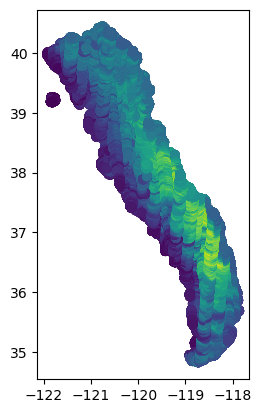

In [84]:
atl06sr_10m_sierras_concat_sorted.plot(column='h_mean')

In [85]:
atl06sr_10m_sierras_concat_sorted.to_pickle('../data/temp/atl06_sr_10m_sierras_concat_sorted.pkl')

### Use the slope and aspect calcs using code Eric sent me:

In [57]:
parms = {
    "poly": south_region_1,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "t0": "2020-10-13T00:00:00Z",
    "t1": "2021-10-13T00:00:00Z"
}

gdf_south_1 = icesat2.atl06p(parms)
coordinates = [[pt.x, pt.y] for pt in gdf_south_1.geometry]

sa_gdf_south_1 = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
print(sa_gdf_south_1[["slope", "aspect", "slope_count"]])

                         slope      aspect  slope_count
time                                                   
2022-12-03 18:59:21   0.986233  149.124175            9
2022-12-03 18:59:21   1.385466  217.695609            9
2022-12-03 18:59:21   0.357490   97.034387            9
2022-12-03 18:59:21   1.082170  161.452563            9
2022-12-03 18:59:21   0.947277  176.709573            9
...                        ...         ...          ...
2022-12-03 18:59:21   7.911249  154.370939            9
2022-12-03 18:59:21   3.747456  276.815998            9
2022-12-03 18:59:21   2.557658  316.661235            9
2022-12-03 18:59:21   3.940489  350.611108            9
2022-12-03 18:59:21  11.690998  327.986921            9

[657997 rows x 3 columns]


In [83]:
sa_gdf_south_1.columns

Index(['slope_count', 'slope', 'aspect', 'file', 'value', 'geometry'], dtype='object')

In [64]:
parms = {
    "poly": south_region_2,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "t0": "2020-10-13T00:00:00Z",
    "t1": "2021-10-13T00:00:00Z"
}

gdf_south_2 = icesat2.atl06p(parms)
coordinates = [[pt.x, pt.y] for pt in gdf_south_2.geometry]

sa_gdf_south_2 = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
print(sa_gdf_south_2[["slope", "aspect", "slope_count"]])

                         slope      aspect  slope_count
time                                                   
2022-12-03 18:59:21   1.537576  169.428299            9
2022-12-03 18:59:21   1.421042  176.315643            9
2022-12-03 18:59:21  28.569673  222.733536            9
2022-12-03 18:59:21   1.545508  170.027203            9
2022-12-03 18:59:21  32.815449  226.301945            9
...                        ...         ...          ...
2022-12-03 18:59:21   9.151491  323.803882            9
2022-12-03 18:59:21  14.257292  319.823014            9
2022-12-03 18:59:21  18.987686  314.638990            9
2022-12-03 18:59:21   8.162915  185.365917            9
2022-12-03 18:59:21   9.549964  187.244978            9

[717982 rows x 3 columns]


In [67]:
parms = {
    "poly": north_region_1,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "t0": "2020-10-13T00:00:00Z",
    "t1": "2021-10-13T00:00:00Z"
}

gdf_north_1 = icesat2.atl06p(parms)
coordinates = [[pt.x, pt.y] for pt in gdf_north_1.geometry]

sa_gdf_north_1 = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
print(sa_gdf_north_1[["slope", "aspect", "slope_count"]])

                         slope      aspect  slope_count
time                                                   
2022-12-03 18:59:21  17.568418  195.203516            9
2022-12-03 18:59:21   5.210582  207.295160            9
2022-12-03 18:59:21   3.258991   33.541071            9
2022-12-03 18:59:21  18.902270   29.872050            9
2022-12-03 18:59:21  23.366675   13.621977            9
...                        ...         ...          ...
2022-12-03 18:59:21   1.787685  108.348345            9
2022-12-03 18:59:21   1.370782  334.792060            9
2022-12-03 18:59:21   1.729474    9.301913            9
2022-12-03 18:59:21   0.606870  206.764022            9
2022-12-03 18:59:21   6.484707  193.040033            9

[1287501 rows x 3 columns]


In [73]:
parms = {
    "poly": north_region_2,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"],
    "t0": "2020-10-13T00:00:00Z",
    "t1": "2021-10-13T00:00:00Z"
}

gdf_north_2 = icesat2.atl06p(parms)
coordinates = [[pt.x, pt.y] for pt in gdf_north_2.geometry]

sa_gdf_north_2 = raster.sample("usgs3dep-10meter-dem", coordinates, {"slope_aspect": True})
print(sa_gdf_north_2[["slope", "aspect", "slope_count"]])

                         slope      aspect  slope_count
time                                                   
2022-12-03 18:59:21   7.839046   80.460829            9
2022-12-03 18:59:21   5.444755  126.510726            9
2022-12-03 18:59:21   6.391526  167.684919            9
2022-12-03 18:59:21   8.230359  177.346968            9
2022-12-03 18:59:21  10.179170  195.095573            9
...                        ...         ...          ...
2022-12-03 18:59:21   3.360252  207.140802            9
2022-12-03 18:59:21   6.430326  123.324587            9
2022-12-03 18:59:21  10.578743  291.477088            9
2022-12-03 18:59:21   4.163764  302.781415            9
2022-12-03 18:59:21  11.515611  320.846061            9

[909652 rows x 3 columns]


In [85]:
gdf_south_1['slope'] = sa_gdf_south_1['slope'].values
gdf_south_2['slope'] = sa_gdf_south_2['slope'].values
gdf_north_1['slope'] = sa_gdf_north_1['slope'].values
gdf_north_2['slope'] = sa_gdf_north_2['slope'].values

gdf_south_1['3dep'] = sa_gdf_south_1['value'].values
gdf_south_2['3dep'] = sa_gdf_south_2['value'].values
gdf_north_1['3dep'] = sa_gdf_north_1['value'].values
gdf_north_2['3dep'] = sa_gdf_north_2['value'].values

gdf_south_1['aspect'] = sa_gdf_south_1['aspect'].values
gdf_south_2['aspect'] = sa_gdf_south_2['aspect'].values
gdf_north_1['aspect'] = sa_gdf_north_1['aspect'].values
gdf_north_2['aspect'] = sa_gdf_north_2['aspect'].values

In [86]:
gdf_south_1_clip = gdf_south_1.clip(poly.to_crs(gdf_south_1.crs))
gdf_south_2_clip = gdf_south_2.clip(poly.to_crs(gdf_south_2.crs))
gdf_north_1_clip = gdf_north_1.clip(poly.to_crs(gdf_north_1.crs))
gdf_north_2_clip = gdf_north_2.clip(poly.to_crs(gdf_north_2.crs))

In [87]:
gdf_slope_concat = pd.concat([gdf_south_1_clip, gdf_south_2_clip, gdf_north_1_clip, gdf_north_2_clip])

In [88]:
gdf_slope_concat['time_acq']=gdf_slope_concat.index

In [89]:
gdf_slope_concat_sorted = gdf_slope_concat.sort_values(by='time_acq',ascending=False)

In [90]:
gdf_slope_concat_sorted

,spot,dh_fit_dx,h_sigma,w_surface_window_final,segment_id,y_atc,x_atc,pflags,region,rms_misfit,...,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag,slope,3dep,aspect,time_acq
time,,,,,,,,,,,,,,,,,,,,,
2021-10-12 07:30:24.762091008,6,0.197039,0.112457,5.061572,787033,-13058.768555,15763947.0,0,6,0.304871,...,POINT (-120.98065 38.72176),1.0,126.000000,1.708231,0.0,0.0,15.320210,456.924466,41.759966,2021-10-12 07:30:24.762091008
2021-10-12 07:30:24.759267328,6,0.178340,0.147901,4.588598,787032,-13058.611328,15763927.0,0,6,0.509555,...,POINT (-120.98063 38.72194),1.0,126.000000,1.708230,0.0,0.0,13.948273,455.139631,42.410061,2021-10-12 07:30:24.759267328
2021-10-12 07:30:24.753623040,6,0.033152,0.050090,3.000000,787030,-13058.166992,15763887.0,0,6,0.204083,...,POINT (-120.98058 38.7223),1.0,126.000000,1.708230,0.0,0.0,6.689053,450.054189,45.426562,2021-10-12 07:30:24.753623040
2021-10-12 07:30:24.750803456,6,0.041241,0.039575,3.000000,787029,-13057.912109,15763867.0,0,6,0.170263,...,POINT (-120.98056 38.72248),1.0,126.000000,1.708230,0.0,0.0,3.758905,449.304424,22.556373,2021-10-12 07:30:24.750803456
2021-10-12 07:30:24.747986176,6,0.034019,0.053511,3.000000,787028,-13057.662109,15763847.0,0,6,0.199658,...,POINT (-120.98053 38.72266),1.0,126.000000,1.708238,0.0,0.0,6.964338,448.442536,13.604666,2021-10-12 07:30:24.747986176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-14 00:50:23.212469760,3,0.084668,0.028482,3.000000,777873,2780.628906,15580344.0,0,6,0.209119,...,POINT (-120.59458 40.35436),1.0,30.000000,-1.115431,0.0,0.0,5.334590,1337.397760,97.186242,2020-10-14 00:50:23.212469760
2020-10-14 00:50:23.209665792,3,0.096522,0.033693,3.000000,777872,2780.615723,15580324.0,0,6,0.229266,...,POINT (-120.59456 40.35454),1.0,25.163657,-1.115510,0.0,0.0,5.834592,1336.374309,101.287483,2020-10-14 00:50:23.209665792
2020-10-14 00:50:23.206865920,3,0.124384,0.042187,3.230203,777871,2780.604736,15580304.0,0,6,0.275251,...,POINT (-120.59454 40.35472),1.0,20.000000,-1.115594,0.0,0.0,7.281284,1334.484404,112.885150,2020-10-14 00:50:23.206865920


<Axes: >

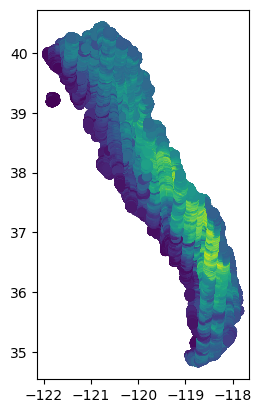

In [81]:
gdf_slope_concat_sorted.plot(column='h_mean')

In [91]:
gdf_slope_concat_sorted.to_pickle('../data/temp/gdf_slope_concat_sorted.pkl')

### Try to download ATL08 canopy info to use as subsetting tool:  
Desiree doesn't trust the canopy product (especially near tree line where trees are somewhat spare) so I'll just use the land classifications from the atl08 ancillary data.

In [56]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "“atl08_top_of_canopy”,",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m_canopy = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m_canopy["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m_canopy["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m_canopy.shape[0]))

Completed in 220.682 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2863054 elevations


In [57]:
atl06_sr_south_10m_canopy

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,geometry,segment_snowcover,segment_landcover,beam_azimuth,segment_watermask,urban_flag,3dep.time,3dep.flags,3dep.value,3dep.file_id
time,,,,,,,,,,,,,,,,,,,,,
2020-10-15 12:31:34.699987712,-3148.572021,3873041.75,19.290844,9,193114,0,634.950395,5,-0.073722,2,...,POINT (-120.02899 34.81882),1.0,20.000000,-2.074179,0.0,0.0,1.354129e+09,0,641.145114,292057776128
2020-10-15 12:31:34.702806528,-3148.572510,3873061.75,9.221133,9,193115,0,629.927112,5,-0.360817,2,...,POINT (-120.02901 34.81899),1.0,20.000000,-2.074179,0.0,0.0,1.354129e+09,0,632.686503,292057776128
2020-10-15 12:31:34.705625600,-3148.638672,3873082.00,13.996363,9,193116,0,620.690577,5,-0.548353,2,...,POINT (-120.02903 34.81917),1.0,20.000000,-2.074179,0.0,0.0,1.354129e+09,0,616.164724,292057776128
2020-10-15 12:31:34.708440320,-3148.765869,3873102.00,16.434500,9,193117,0,608.519892,5,-0.644044,2,...,POINT (-120.02905 34.81935),1.0,76.881738,-2.074168,0.0,0.0,1.354129e+09,0,609.971439,292057776128
2020-10-15 12:31:34.711252480,-3148.905518,3873122.00,17.522057,9,193118,0,595.407868,5,-0.683031,2,...,POINT (-120.02907 34.81953),1.0,126.000000,-2.074159,0.0,0.0,1.354129e+09,0,596.619403,292057776128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-09 19:20:11.517164288,-6826.478027,4169123.50,3.000000,13,207882,0,2409.612553,2,0.009453,2,...,POINT (-119.52317 37.478),1.0,111.000000,-1.423419,0.0,0.0,1.354129e+09,0,2408.041054,188978561024
2021-10-09 19:20:11.518931712,-6739.615723,4171549.50,4.172413,13,208003,0,2355.608585,1,0.161857,2,...,POINT (-119.52675 37.49968),1.0,111.000000,-1.753762,0.0,0.0,1.354129e+09,0,2356.099821,188978561024
2021-10-09 19:20:11.519975680,-6826.544922,4169143.75,3.000000,13,207883,0,2409.676360,2,-0.001007,2,...,POINT (-119.5232 37.47818),1.0,111.000000,-1.423419,0.0,0.0,1.354129e+09,0,2408.990125,188978561024


In [58]:
atl06_sr_south_10m_canopy.columns

Index(['y_atc', 'x_atc', 'w_surface_window_final', 'cycle', 'segment_id',
       'pflags', 'h_mean', 'spot', 'dh_fit_dx', 'region', 'rms_misfit',
       'h_sigma', 'rgt', 'gt', 'n_fit_photons', 'geometry',
       'segment_snowcover', 'segment_landcover', 'beam_azimuth',
       'segment_watermask', 'urban_flag', '3dep.time', '3dep.flags',
       '3dep.value', '3dep.file_id'],
      dtype='object')

In [61]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_top_of_canopy",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m_canopy = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m_canopy["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m_canopy["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m_canopy.shape[0]))

Completed in 117.763 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 531107 elevations


In [ ]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_top_of_canopy",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m_canopy = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m_canopy["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m_canopy["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m_canopy.shape[0]))

In [64]:
# Build ATL06 Request
parms = {
    "poly": south_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": ["atl08_top_of_canopy", "atl08_ground"],
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_south_10m_canopy = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_south_10m_canopy["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_south_10m_canopy["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_south_10m_canopy.shape[0]))

Completed in 199.476 seconds of wall-clock time
Reference Ground Tracks: [ 326  501  562  623  684  707  768 1004 1065 1088 1126 1149 1210   59
  120  181  204  265  646 1271  585  143  242]
Cycles: [ 9 10 11 12 13]
Received 2562128 elevations


In [67]:
atl06_sr_south_10m_canopy.columns

Index(['y_atc', 'x_atc', 'w_surface_window_final', 'cycle', 'segment_id',
       'pflags', 'h_mean', 'spot', 'dh_fit_dx', 'region', 'rms_misfit',
       'h_sigma', 'rgt', 'gt', 'n_fit_photons', 'geometry',
       'segment_snowcover', 'segment_landcover', 'beam_azimuth',
       'segment_watermask', 'urban_flag', '3dep.time', '3dep.flags',
       '3dep.value', '3dep.file_id'],
      dtype='object')

In [69]:
# Build ATL06 Request
parms = {
    "poly": region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-10meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_10m_sierras = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_10m_sierras["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_10m_sierras["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_10m_sierras.shape[0]))

Completed in 554.368 seconds of wall-clock time


KeyError: 'rgt'

In [62]:
atl06_sr_south_10m_canopy.columns

Index(['y_atc', 'x_atc', 'w_surface_window_final', 'cycle', 'segment_id',
       'pflags', 'h_mean', 'spot', 'dh_fit_dx', 'region', 'rms_misfit',
       'h_sigma', 'rgt', 'gt', 'n_fit_photons', 'geometry',
       'segment_snowcover', 'segment_landcover', 'beam_azimuth',
       'segment_watermask', 'urban_flag', '3dep.time', '3dep.flags',
       '3dep.value', '3dep.file_id'],
      dtype='object')

In [63]:
atl06_sr_south_10m_canopy['h_mean']

time
2020-10-15 12:31:34.699988736     635.792556
2020-10-15 12:31:34.702808320     631.148544
2020-10-15 12:31:34.705628672     623.871102
2020-10-15 12:31:34.711254016     599.558481
2020-10-15 12:31:34.719687424     572.906007
                                    ...     
2021-10-09 19:20:11.110191360    2370.047629
2021-10-09 19:20:11.113026048    2369.882678
2021-10-09 19:20:11.115866880    2372.479418
2021-10-09 19:20:11.400632832    2562.052054
2021-10-09 19:20:11.403454976    2555.940799
Name: h_mean, Length: 531107, dtype: float64

In [ ]:
geojson = earthdata.tnm(short_name='Digital Elevation Model (DEM) 1 meter', polygon=north_region)

In [ ]:
# Build ATL06 Request
parms = {
    "poly": north_region,
    "srt": icesat2.SRT_LAND,
    "cnf": icesat2.CNF_SURFACE_HIGH,
    "atl08_class": "atl08_ground",
    "ats": 10.0,
    "cnt": 10,
    "len": 40.0,
    "res": 20.0,
    "maxi": 10,
    "atl06_fields": ["ground_track/ref_azimuth"],
    "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth", "segment_watermask", "urban_flag"], # 0=ice free water; 1=snow free land; 2=snow; 3=ice
    "samples": {"3dep": {"asset": "usgs3dep-1meter-dem", "catalog": geojson}}, 
    't0': '2020-10-13T00:00:00Z',
    't1': '2021-10-13T00:00:00Z'
}
# for landcover codes, see pg 60 of https://icesat-2.gsfc.nasa.gov/sites/default/files/page_files/ICESat2_ATL08_ATBD_r006.pdf

# Latch Start Time
perf_start = time.perf_counter()

# Request ATL06 Data
atl06_sr_north = icesat2.atl06p(parms)

# Latch Stop Time
perf_stop = time.perf_counter()

# Display Statistics
perf_duration = perf_stop - perf_start
print("Completed in {:.3f} seconds of wall-clock time".format(perf_duration))
print("Reference Ground Tracks: {}".format(atl06_sr_north["rgt"].unique()))
print("Cycles: {}".format(atl06_sr_north["cycle"].unique()))
print("Received {} elevations".format(atl06_sr_north.shape[0]))